In [1]:
from pathlib import Path

from maite_datasets.object_detection import SkySeaLand

data_root = Path("./data")

# Download once into ./data/skysealand; exports reuse the cached download.
SkySeaLand(root=data_root, image_set="base", download=True)

split_paths = {name: data_root / f"skysealand_datamaite_{name}" for name in ("train", "test")}
for image_set in split_paths:
    SkySeaLand(root=data_root, image_set=image_set, as_datamaite=True)

print("\n".join(f"{name}: {path}" for name, path in split_paths.items()))

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train: data/skysealand_datamaite_train
test: data/skysealand_datamaite_test


In [2]:
from dataeval_flow import load_dataset

train_ds = load_dataset(split_paths["train"], dataset_format="coco")
image, target, _ = train_ds[0]

print(f"Images:      {len(train_ds)}")
print(f"Image shape: {image.shape}")
print(f"Boxes:       {len(target.boxes)}")
print(f"Classes:     {train_ds.metadata['index2label']}")

Images:      1048
Image shape: (3, 672, 1584)
Boxes:       3
Classes:     {0: 'airplane', 1: 'boat', 2: 'car', 3: 'ship'}


In [3]:
from dataeval_flow import PipelineConfig, run_task
from dataeval_flow.config import (
    CocoDatasetConfig,
    MetadataPolicyConfig,
    SourceConfig,
    TaskConfig,
    ViewConfig,
    ViewOperation,
)
from dataeval_flow.workflows.metadata_triage import MetadataTriageConfig

triage_config = PipelineConfig(
    metadata=[MetadataPolicyConfig(name="skysealand_factors", intrinsic_factors=["visual", "pixel"])],
    datasets=[CocoDatasetConfig(name="skysealand_train", path=str(split_paths["train"]))],
    views=[
        ViewConfig(
            name="sample300",
            operations=[
                ViewOperation(type="Shuffle", params={"seed": 0}),
                ViewOperation(type="Limit", params={"size": 300}),
            ],
        )
    ],
    sources=[SourceConfig(name="train_src", dataset="skysealand_train", view="sample300")],
    workflows=[MetadataTriageConfig(name="triage", metadata="skysealand_factors")],
    tasks=[TaskConfig(name="triage_train", workflow="triage", sources="train_src")],
)

triage_result = run_task(triage_config.tasks[0], triage_config, data_dir=Path("."), cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_metadata.py:231: UserWarning: `file_name`, `file_path`, `label_file` and `original_id` were dropped: nearly every row holds a different value, so the column identifies rows rather than grouping them, and it is not numeric so there is no order along which to cut it into groups. Map the values onto a smaller vocabulary to keep the factor. See Metadata.dropped_factors.
  per_target=metadata.multi_target,


/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_binning.py:417: UserWarning: `height`, `instance_brightness`, `instance_contrast`, `instance_darkness`, `instance_entropy`, `instance_kurtosis`, `instance_mean`, `instance_sharpness`, `instance_skew`, `instance_std`, `instance_var`, `instance_zeros`, `num_annotations`, `unit_brightness`, `unit_contrast`, `unit_darkness`, `unit_entropy`, `unit_kurtosis`, `unit_mean`, `unit_sharpness`, `unit_skew`, `unit_std`, `unit_var`, `unit_zeros` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  factor_info = metadata.factor_info
/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_binning.py:417: UserWarning: Declared cuts left bins unused: instance_kurtosis (37 of 40 bins hold rows). The encoding stil

In [4]:
findings = triage_result.output.raw.findings
degenerate = sorted({f.factor for f in findings if f.category == "degenerate"})
unbinned = sorted({f.factor for f in findings if f.category == "unbinned"})

print(f"Factors:              {triage_result.output.raw.factor_count}")
print(f"Findings:             {len(findings)} ({triage_result.metadata.blocking} blocking)")
print(f"Degenerate (exclude): {degenerate}")
print(f"Need explicit bins:   {len(unbinned)} factors")

Factors:              28
Findings:             38 (4 blocking)
Degenerate (exclude): ['instance_missing', 'label_file_exists', 'unit_missing']
Need explicit bins:   25 factors


In [5]:
config_path = Path("end_to_end.yaml")
print(config_path.read_text())

# End-to-end pipeline — clean, profile, and split one dataset
#
# This is the single source of truth for the `end_to_end` tutorial. The notebook
# loads this exact file, and the container runs this exact file — nothing in the
# pipeline is defined in Python.
#
# All paths are relative to the data root:
#   * notebook  — docs/source/notebooks/
#   * container — the directory bind-mounted at /dataeval
#
# Run it locally:
#   dataeval-flow --config end_to_end.yaml --data . --output ./output --cache ./cache -v
#
# yaml-language-server: $schema=../../../config/params.schema.json

# Pin every stochastic component (clustering, splitting) so re-runs match.
seed: 42

# -----------------------------------------------------------------------------
# METADATA — which factors bias analysis reads, and how they are encoded
# -----------------------------------------------------------------------------
metadata:
  - name: skysealand_factors
    # SkySeaLand ships no telemetry, so the only factors avai

In [6]:
from dataeval_flow import load_config

config = load_config(config_path)

print(f"Datasets:   {[d.name for d in config.datasets]}")
print(f"Sources:    {[s.name for s in config.sources]}")
print(f"Extractors: {[e.name for e in config.extractors]}")
print(f"Workflows:  {[(w.name, w.type) for w in config.workflows]}")
print(f"Tasks:      {[(t.name, t.workflow, t.sources) for t in config.tasks]}")

Datasets:   ['skysealand_train', 'skysealand_test']
Sources:    ['train_src', 'test_src']
Extractors: ['bovw_ext']
Workflows:  [('clean', 'data-cleaning'), ('profile', 'data-analysis'), ('split', 'data-splitting')]
Tasks:      [('clean_train', 'clean', 'train_src'), ('profile_splits', 'profile', ['train_src', 'test_src']), ('split_train', 'split', 'train_src')]


In [7]:
from dataeval_flow import run_tasks

results = run_tasks(config, data_dir=Path("."), cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/data_cleaning/_workflow.py:219: UserWarning: Declared cuts left bins unused: instance_kurtosis (37 of 40 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  td = metadata.rows_at(metadata.label_level).select("item_index", "target_index", "class_label")


/builds/jatic/aria/dataeval-flow/src/dataeval_flow/_binning.py:152: UserWarning: Declared cuts left bins unused: instance_kurtosis (37 of 40 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  export(path)


/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/data_analysis/_workflow.py:361: UserWarning: Declared cuts left bins unused: instance_entropy (18 of 20 bins hold rows), instance_kurtosis (34 of 40 bins hold rows), instance_skew (31 of 32 bins hold rows). The encoding still applies and the codes are unchanged; this is the data no longer matching the policy, not an error. Call reencode() to refit — which moves codes — or leave it and read the empty groups as the finding they are.
  bal_result = Balance(factor_source=factor_source).evaluate(data.metadata)
/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/dataeval/core/_mutual_info.py:91: RuntimeWarning: divide by zero encountered in log
  return float(expected_mutual_information(rescaled(contingency, n_effective), n_effective))


/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/data_splitting/_workflow.py:173: UserWarning: `file_name`, `file_path`, `label_file` and `original_id` were dropped: nearly every row holds a different value, so the column identifies rows rather than grouping them, and it is not numeric so there is no order along which to cut it into groups. Map the values onto a smaller vocabulary to keep the factor. See Metadata.dropped_factors.
  balance_output = Balance().evaluate(metadata)
/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/data_splitting/_workflow.py:173: UserWarning: `height`, `num_annotations` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  balance_output = Balance().evaluate(metadata)


In [8]:
for name, result in results.items():
    status = "OK " if result.success else "FAIL"
    warnings = sum(1 for f in result.output.report.findings if f.severity == "warning") if result.success else 0
    elapsed = result.metadata.execution_time_s or 0.0
    print(f"[{status}] {name:<16} {result.type:<16} {elapsed:>6.1f}s  {warnings} warning(s)")
    for error in result.errors:
        print(f"         {error}")

[OK ] clean_train      data-cleaning       0.6s  1 warning(s)
[OK ] profile_splits   data-analysis       2.5s  3 warning(s)
[OK ] split_train      data-splitting      4.9s  1 warning(s)


In [9]:
assert all(r.success for r in results.values()), [r.errors for r in results.values() if not r.success]

In [10]:
clean_result, profile_result, split_result = results["clean_train"], results["profile_splits"], results["split_train"]

In [11]:
for result in results.values():
    print(result.report(detailed=False))


  DATA CLEANING COMPLETE. DATASET: 300 ITEMS. MODE: ADVISORY.
  Timestamp:    2026-09-25T21:37:29.727686+00:00
  Duration:     0.64s
  Source:       train_src (skysealand_train[sample300])
  Model:        bovw_ext (bovw)
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  Image Outliers ................................................ 24 images (8.0%)  [!!]
  Target Outliers ............................................. 169 targets (4.0%)  [..]
  Classwise Outliers ................. worst: ship (20.8%), 1/4 classes over 12.0%  [..]
  Label Distribution ....................... 4 classes, 300 items, imbalance 2.6:1  [..]

  Health: 1 warning(s) [!!] — review flagged findings

------------------------------------------------------------------------------------------
  METADATA FACTORS
------------------------------------------------------------------------------------------
  Encoding:        f238d0540d8e4039
  Auto-bin method

In [12]:
for result in results.values():
    print(f"\n{result.type}")
    for finding in result.output.report.findings:
        marker = {"warning": "[!!]", "ok": "[ok]"}.get(finding.severity, "[..]")
        headline = (finding.description or "").splitlines()
        print(f"  {marker} {finding.title:<34} {headline[0][:60] if headline else ''}")


data-cleaning
  [!!] Image Outliers                     24 images (8.0%) flagged as outliers.
  [..] Target Outliers                    169 bounding-box targets (4.0%) flagged as outliers.
  [..] Classwise Outliers                 Most outliers in ship (20.8%). 1/4 classes exceed 12.0% thre
  [..] Label Distribution                 4 classes, 300 items.

data-analysis
  [!!] Image Quality                      27 images flagged across 2 split(s).
  [ok] Redundancy                         No duplicates detected.
  [..] Label Balance                      4 classes across 2 split(s).
  [!!] Bias                               24 metadata factors checked across 2 split(s).
  [ok] Label Overlap                      All 4 classes shared across splits.
  [!!] Label Parity                       Chi-squared test: 1/1 pair(s) significantly different.
  [ok] Leakage                            No cross-split duplicates detected.

data-splitting
  [..] Class distribution (full dataset)  Max/min clas

In [13]:
raw = clean_result.output.raw

outlier_issues = raw.img_outliers["issues"]
outlier_indices = sorted({issue["item_index"] for issue in outlier_issues})
near_groups = raw.duplicates["items"].get("near", [])

print(f"Image outliers:        {len(outlier_indices)} images, {len(outlier_issues)} flags")
print(f"Near-duplicate groups: {len(near_groups)}")

Image outliers:        24 images, 29 flags
Near-duplicate groups: 0


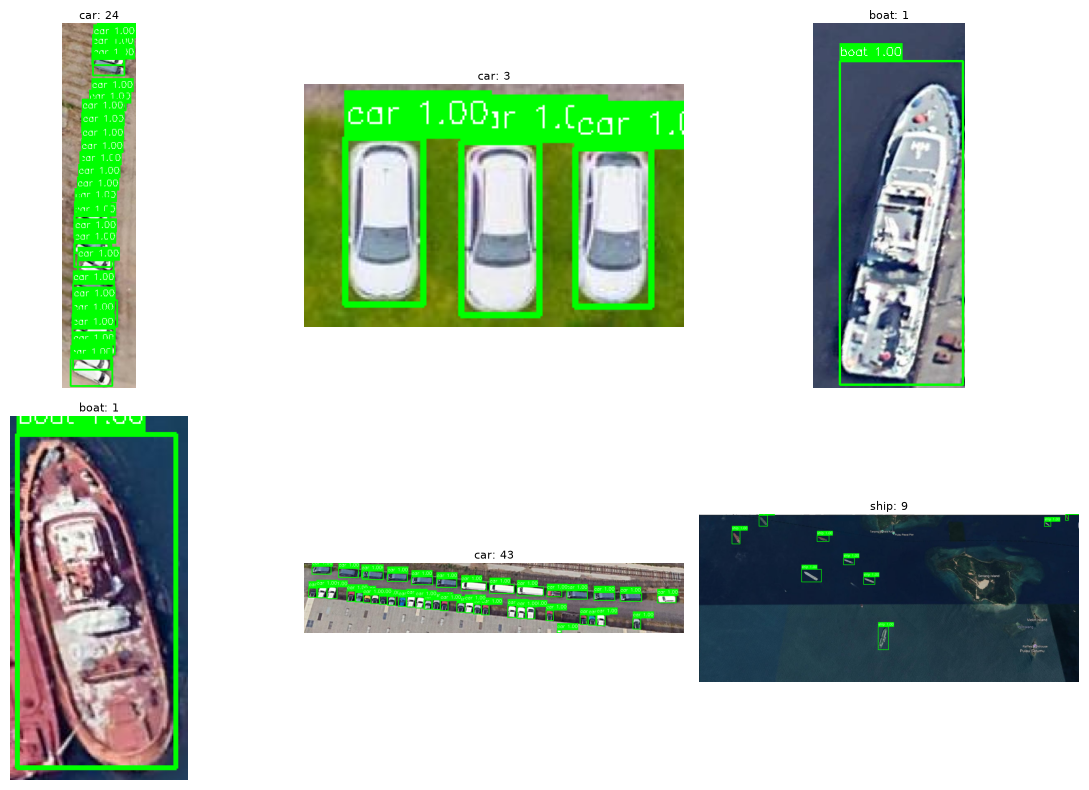

In [14]:
from dataeval_plots import plot

assert clean_result.dataset is not None

if outlier_indices:
    _ = plot(
        clean_result.dataset,
        indices=outlier_indices[:6],
        images_per_row=3,
        figsize=(12, 8),
        show_labels=True,
    )

In [15]:
print(f"Splits analyzed: {profile_result.metadata.split_names}")

for pair, section in profile_result.output.raw.cross_split.items():
    cs = section.model_dump()
    leakage = cs["redundancy"]["duplicate_leakage"]
    overlap = cs["label_health"]["label_overlap"]
    parity = cs["label_health"]["label_parity"]

    only = {key: value for key, value in overlap.items() if key.endswith("_only")}

    print(f"\n{pair}")
    print(f"  Duplicate leakage:  {leakage['exact_count']} exact, {leakage['near_count']} near")
    print(f"  Shared classes:     {overlap['shared_classes']}")
    print(f"  Classes in one split only: {only}")
    print(
        f"  Label parity:       chi2={parity['chi_squared']:.2f}, "
        f"p={parity['p_value']:.4f}, significant={parity['significant']}"
    )

Splits analyzed: ['train_src', 'test_src']

train_src_vs_test_src
  Duplicate leakage:  0 exact, 0 near
  Shared classes:     ['airplane', 'boat', 'car', 'ship']
  Classes in one split only: {'train_src_only': [], 'test_src_only': []}
  Label parity:       chi2=11.76, p=0.0082, significant=True


In [16]:
fold = split_result.output.raw.folds[0]

print(f"Split sizes: {split_result.metadata.split_sizes}")
print(f"Stratified:  {split_result.metadata.stratified}")
print(f"Train indices (first 10): {fold.train_indices[:10]}")
print(f"Val   indices (first 10): {fold.val_indices[:10]}")
print(f"Test  indices (first 10): {split_result.output.raw.test_indices[:10]}")

Split sizes: {'train': 220, 'val': 20, 'test': 60}
Stratified:  True
Train indices (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 10, 14]
Val   indices (first 10): [9, 11, 34, 35, 77, 83, 101, 103, 116, 141]
Test  indices (first 10): [8, 12, 13, 17, 25, 26, 27, 38, 43, 44]


In [17]:
output_dir = Path("./output/end_to_end")

for name, result in results.items():
    written = result.export(output_dir / f"{name}.json")
    print(f"{written}  ({written.stat().st_size:,} bytes)")

output/end_to_end/clean_train.json  (169,322 bytes)
output/end_to_end/profile_splits.json  (668,477 bytes)
output/end_to_end/split_train.json  (23,174 bytes)


In [18]:
import json

envelope = json.loads((output_dir / "split_train.json").read_text())

print(f"Top-level keys: {list(envelope)}")
print(f"Tool:           {envelope['metadata']['tool']} {envelope['metadata']['tool_version']}")
print(f"Timestamp:      {envelope['metadata']['timestamp']}")
print(f"Sources:        {envelope['metadata']['source_descriptions']}")

Top-level keys: ['kind', 'metadata', 'health', 'raw', 'report']
Tool:           dataeval-flow 0.2.3.dev232+gcb4a8cb6a
Timestamp:      2026-09-25T21:37:39.587062Z
Sources:        ['train_src (skysealand_train[sample300])']
